# 02 — Error Analysis

This notebook inspects validation errors to guide improvements:
- False positives (wrong merges)
- False negatives (missed matches)
- Hard negatives (similar but different)
- Singleton mistakes
- Low/high confidence errors

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
from business_entity_resolution.config import load_config
from business_entity_resolution.data_loader import load_train_data
from business_entity_resolution.preprocessing import preprocess_sources
from business_entity_resolution.ground_truth import parse_ground_truth

cfg = load_config('../config.yaml')
data = load_train_data(cfg)
data = preprocess_sources(data, cfg)
gt_map = parse_ground_truth(data.ground_truth)

In [2]:
# Load validation predictions
val_df = pd.read_csv(cfg.paths.models_dir / 'val_predictions.csv')
threshold = cfg.threshold.selected or cfg.threshold.default
print(f'Threshold: {threshold}')
print(f'Validation pairs: {len(val_df)}')
print(f'Positives: {val_df["label"].sum()}')

Threshold: 0.5
Validation pairs: 233267
Positives: 33692


In [3]:
# FALSE POSITIVES: predicted match but actually different
fp = val_df[(val_df['probability'] >= threshold) & (val_df['label'] == 0)]
print(f'False positives: {len(fp)}')

# Merge with source data for inspection
pool = pd.concat([data.source2, data.source3])
s1_lkp = data.source1.set_index('entity_id')
pool_lkp = pool.set_index('entity_id')

for _, row in fp.head(10).iterrows():
    s1 = s1_lkp.loc[row['source1_id']]
    c = pool_lkp.loc[row['candidate_id']]
    print(f"\n--- FP: {row['source1_id']} ↔ {row['candidate_id']}  (prob={row['probability']:.3f}) ---")
    print(f"  S1 name   : {s1.get('business_name', '')}")
    print(f"  S1 name_n : {s1.get('business_name_normalized', '')}")
    print(f"  C  name   : {c.get('business_name', '')}")
    print(f"  C  name_n : {c.get('business_name_normalized', '')}")
    print(f"  S1 addr   : {s1.get('business_address', '')}")
    print(f"  C  addr   : {c.get('business_address', '')}")
    print(f"  S1 country: {s1.get('country', '')}")
    print(f"  C  country: {c.get('country', '')}")

False positives: 1212



--- FP: S1-101072332 ↔ S2-187995656  (prob=0.648) ---
  S1 name   : Family Group
  S1 name_n : family group
  C  name   : Family Gfereon Group
  C  name_n : family gfereon group
  S1 addr   : Syracuse, 100 Buckingham Avenue, NY
  C  addr   : 00338 JAMESVILLE AVE, SYRACUSE, NY
  S1 country: US
  C  country: US

--- FP: S1-101072332 ↔ S2-303232317  (prob=0.806) ---
  S1 name   : Family Group
  S1 name_n : family group
  C  name   : Family Gren Group
  C  name_n : family gren group
  S1 addr   : Syracuse, 100 Buckingham Avenue, NY
  C  addr   : 00338 JAMESVILLE AVENUE, SYRACUSE, NY
  S1 country: US
  C  country: US

--- FP: S1-101072332 ↔ S2-2842491  (prob=0.849) ---
  S1 name   : Family Group
  S1 name_n : family group
  C  name   : Family Group Partners
  C  name_n : family group partners
  S1 addr   : Syracuse, 100 Buckingham Avenue, NY
  C  addr   : 107 BUCKINGHAM AVE, SYRACUSE, NY
  S1 country: US
  C  country: US

--- FP: S1-101368115 ↔ S3-485552736  (prob=0.725) ---
  S1 name   : 

In [4]:
# FALSE NEGATIVES: true match but not predicted
fn = val_df[(val_df['probability'] < threshold) & (val_df['label'] == 1)]
print(f'False negatives: {len(fn)}')

for _, row in fn.head(10).iterrows():
    s1 = s1_lkp.loc[row['source1_id']]
    c = pool_lkp.loc[row['candidate_id']]
    print(f"\n--- FN: {row['source1_id']} ↔ {row['candidate_id']}  (prob={row['probability']:.3f}) ---")
    print(f"  S1 name   : {s1.get('business_name', '')}")
    print(f"  C  name   : {c.get('business_name', '')}")
    print(f"  S1 addr   : {s1.get('business_address', '')}")
    print(f"  C  addr   : {c.get('business_address', '')}")
    print(f"  S1 country: {s1.get('country', '')}")
    print(f"  C  country: {c.get('country', '')}")

False negatives: 218

--- FN: S1-102463259 ↔ S2-159883522  (prob=0.237) ---
  S1 name   : Heritage Digital Inc
  C  name   : Heritage lnc Center
  S1 addr   : 5800 Mount Evans Court, Sacramento, CA
  C  addr   : 5782 MOUNT EVANS COURT, FOOTHILL FARMS, CA
  S1 country: US
  C  country: US

--- FN: S1-104195520 ↔ S3-889537471  (prob=0.451) ---
  S1 name   : New Agro Pvt Ltd
  C  name   : न्यू एग्रो प्रा. लि.
  S1 addr   : Padouli Shri Niwas, Tiwari Mahawa, Deoria, Uttar Pradesh
  C  addr   : Deoria, उत्तर प्रदेश, Deoria, Padouli Shri Niwas
  S1 country: India
  C  country: India

--- FN: S1-106430204 ↔ S2-2463944  (prob=0.444) ---
  S1 name   : Apex Indian Solutions
  C  name   : एपेक्स इंडियन सॉल्यूशंस
  S1 addr   : 517 Sector 21, Panchkula, Haryana
  C  addr   : 51 SECTOR 21, PANCHKULA, हरियाणा
  S1 country: India
  C  country: India

--- FN: S1-109666175 ↔ S2-523332136  (prob=0.007) ---
  S1 name   : Village Of Somers Community Services
  C  name   : Village  Of Somers Community
  S1 

In [5]:
# BLOCKING MISSES: true matches never generated as candidates
val_s1_ids = val_df['source1_id'].unique()
all_candidates = set(zip(val_df['source1_id'], val_df['candidate_id']))

blocking_misses = []
for s1_id in val_s1_ids:
    true_matches = gt_map.get(s1_id, set())
    for true_id in true_matches:
        if (s1_id, true_id) not in all_candidates:
            blocking_misses.append((s1_id, true_id))

print(f'Blocking misses: {len(blocking_misses)}')
for s1_id, true_id in blocking_misses[:10]:
    print(f'  {s1_id} → {true_id}')

Blocking misses: 789
  S1-104344504 → S3-151529493
  S1-104372704 → S3-454049713
  S1-105451803 → S2-975570763
  S1-109001937 → S3-738631304
  S1-109719198 → S2-331013656
  S1-109719198 → S2-315397359
  S1-111707068 → S2-900849347
  S1-113519762 → S2-815027556
  S1-113610230 → S2-900434103
  S1-11525301 → S2-969587175


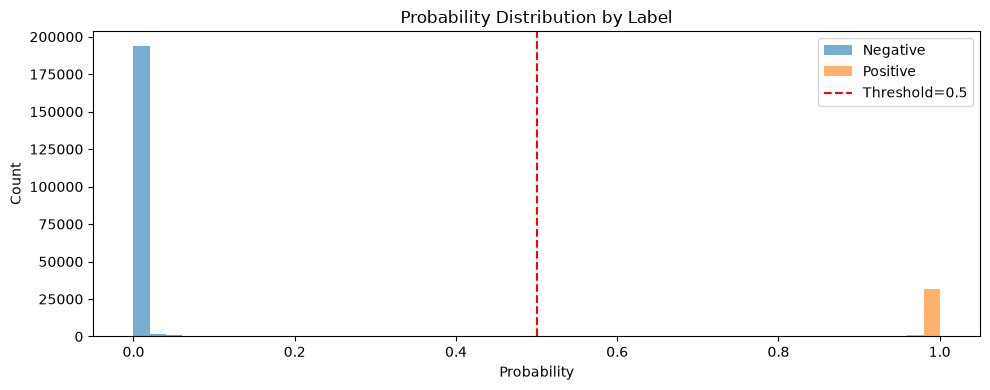

In [6]:
# Probability distribution
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_df[val_df['label']==0]['probability'], bins=50, alpha=0.6, label='Negative')
ax.hist(val_df[val_df['label']==1]['probability'], bins=50, alpha=0.6, label='Positive')
ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold={threshold}')
ax.set_xlabel('Probability')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Probability Distribution by Label')
plt.tight_layout()
plt.show()